# Task 1: Exploratory Data Analysis (EDA)

This notebook covers the initial exploration of the Brent Oil Prices dataset, including:
1. Data Loading and Cleaning
2. Trend Analysis
3. Volatility Analysis (Log Returns)
4. Stationarity Testing (Augmented Dickey-Fuller Test)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import numpy as np
import os

# Set style
sns.set(style="whitegrid")

# Paths
DATA_PATH = r"../data/BrentOilPrices.csv"
OUTPUT_DIR = r"../docs/images"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

## 1. Load Data

In [3]:
def load_data(path):
    df = pd.read_csv(path)
    # Using format='mixed' to handle inconsistent date formats
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)
    return df

df = load_data(DATA_PATH)
print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (9011, 1)


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


## 2. Trend Analysis

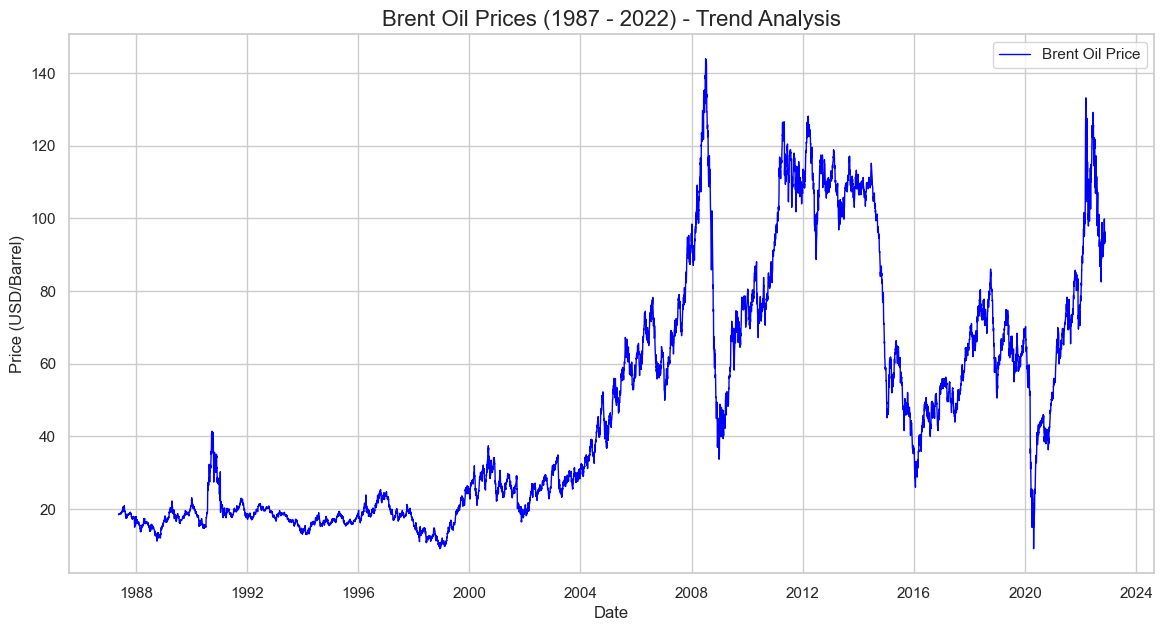

In [4]:
def plot_trend(df):
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['Price'], label='Brent Oil Price', color='blue', linewidth=1)
    plt.title('Brent Oil Prices (1987 - 2022) - Trend Analysis', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD/Barrel)', fontsize=12)
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'price_trend.png'))
    plt.show()

plot_trend(df)

## 3. Volatility Analysis

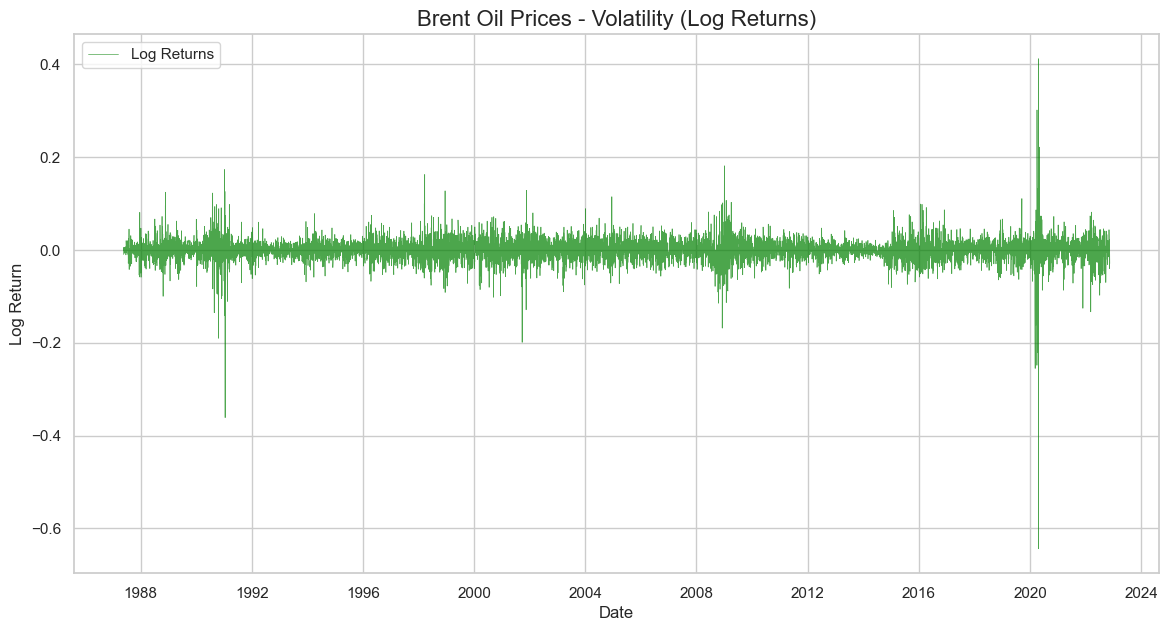

In [5]:
def plot_volatility(df):
    df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))
    
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['Log_Returns'], label='Log Returns', color='green', alpha=0.7, linewidth=0.5)
    plt.title('Brent Oil Prices - Volatility (Log Returns)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Log Return', fontsize=12)
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'volatility.png'))
    plt.show()
    return df

df = plot_volatility(df)

## 4. Stationarity Check (ADF Test)

In [6]:
def check_stationarity(series, name="Price"):
    result = adfuller(series.dropna())
    print(f'\nAugmented Dickey-Fuller Test for {name}:')
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    
    if result[1] < 0.05:
        print(f"Result: The {name} series is likely Stationary.")
    else:
        print(f"Result: The {name} series is likely Non-Stationary.")

check_stationarity(df['Price'], "Raw Price")
check_stationarity(df['Log_Returns'], "Log Returns")


Augmented Dickey-Fuller Test for Raw Price:
ADF Statistic: -1.993856
p-value: 0.289274
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The Raw Price series is likely Non-Stationary.

Augmented Dickey-Fuller Test for Log Returns:
ADF Statistic: -16.427113
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The Log Returns series is likely Stationary.
